# Pitching+: reconciling Stuff+ and Location+ on run value

`docs/purpose.md`'s next stage after Stuff+ and Location+ is Pitching+: "reward
maximized Location+ w/ weight for Stuff+." Before picking weights by hand, this
notebook asks the empirical question directly: **as pitches actually resolve into
run value, how much of that is explained by Stuff+ versus Location+?**

Both metrics already ship as derived scores in `pitching_plus/scripts/`. This
notebook only *loads* them via `add_stuff_plus`/`add_location_plus` and studies the
relationship between them and realized outcomes. It does not re-derive either model
(see `stuff.py`/`location.py` and their notebooks for that logic).

Ground truth for "run value" is Statcast's `delta_pitcher_run_exp` (positive = favors
the pitcher), the same target `location_run_value` was trained to predict
out-of-fold, but used here purely as an outcome to explain, never refit.

**Methods, in order:** a quick sanity check on the inputs themselves &rarr; raw vs.
log-transformed correlation &rarr; pitch-level OLS &rarr;
pitcher x pitch-type x season WLS (where single-pitch noise cancels) with a variance
decomposition &rarr; a reliability-threshold sweep and a year-over-year stickiness check,
both directly motivated by FanGraphs' [Stuff+/Location+/Pitching+ primer](https://library.fangraphs.com/pitching/stuff-location-and-pitching-primer/)
&rarr; PCA (as an independence check, not a weighting method) &rarr; a season holdout to
confirm the relationship generalizes &rarr; a pitch-sequencing significance test &rarr; a
whiff-rate cross-check. All of it is plain OLS/WLS/PCA on columns the scripts already
compute; nothing here retrains a model.

In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
import statsmodels.api as sm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pitching_plus").is_dir():
            return candidate
    raise RuntimeError("Could not locate repo root (expected a 'pitching_plus' directory in a parent).")


REPO_ROOT = find_repo_root(Path.cwd())
SCRIPTS_DIR = REPO_ROOT / "pitching_plus" / "scripts"
DATA_PATH = REPO_ROOT / "data" / "MLB_2021-2025.csv"

sys.path.insert(0, str(SCRIPTS_DIR))

from stuff import add_stuff_plus, REQUIRED_COLS as STUFF_REQUIRED_COLS
from location import (
    add_location_plus,
    REQUIRED_COLS as LOCATION_REQUIRED_COLS,
    BASE_STATE_COLS,
    MIN_PITCHES_FOR_SCORE,
)

In [2]:
# Chart palette -- kept fixed across every chart in this notebook so color maps
# to the same entity everywhere: orange = Stuff+, blue = Location+, violet = a
# combined/"both" model. Values are the repo's standard categorical/diverging
# slots, not picked per-chart.
COLOR_STUFF = "#eb6834"
COLOR_LOC = "#2a78d6"
COLOR_BOTH = "#4a3aa7"
COLOR_GRID = "#e1e0d9"
COLOR_AXIS = "#c3c2b7"
COLOR_TEXT = "#0b0b0b"
COLOR_MUTED = "#898781"
DIVERGING_NEG, DIVERGING_MID, DIVERGING_POS = "#e34948", "#f0efec", "#2a78d6"

SEQUENTIAL_BLUE = LinearSegmentedColormap.from_list(
    "sequential_blue", ["#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"]
)
DIVERGING_RUN_VALUE = LinearSegmentedColormap.from_list(
    "diverging_rv", [DIVERGING_NEG, DIVERGING_MID, DIVERGING_POS]
)

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": COLOR_AXIS,
    "axes.labelcolor": COLOR_TEXT,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": COLOR_GRID,
    "grid.linewidth": 0.8,
    "text.color": COLOR_TEXT,
    "xtick.color": COLOR_MUTED,
    "ytick.color": COLOR_MUTED,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def sig_word(p, alpha=0.05):
    return "statistically significant" if p < alpha else "not statistically significant"

## Load data through the pipeline scripts

`add_stuff_plus`/`add_location_plus` each declare their own `REQUIRED_COLS`; we load
the union of both (plus `description`, needed later for a whiff-rate cross-check) with
`usecols` so we're not pulling all ~119 raw Statcast columns for a 3.5M-row CSV.
`add_location_plus` uses the cached, already-trained per-pitch-type models under
`pitching_plus/models/`; it does not retrain.

In [3]:
usecols = sorted(set(STUFF_REQUIRED_COLS) | set(LOCATION_REQUIRED_COLS) | set(BASE_STATE_COLS) | {"description"})

t0 = time.time()
raw_df = pd.read_csv(DATA_PATH, usecols=usecols)
print(f"Loaded {len(raw_df):,} raw pitches in {time.time() - t0:.0f}s")

t0 = time.time()
df = add_stuff_plus(raw_df)
df = add_location_plus(df)
print(f"Scored Stuff+ and Location+ in {time.time() - t0:.0f}s")

del raw_df

Loaded 3,565,743 raw pitches in 15s


Scored Stuff+ and Location+ in 11s


## Sanity-checking the inputs before trusting them

A quick check before regressing anything: `stuff.py` (retooled 9/4/2026, see
`docs/dev_log.md`) trains a per-pitch-type model against
`delta_pitcher_run_exp`, so it has no guaranteed sign the way the old PCA
composite's sign-anchoring did. `release_speed` is one of its inputs and a
real predictor of suppressed run value on its own, so within any single
pitch type a pitch's own `release_speed` should still correlate positively
with its own `pitch_stuff_plus` -- an empirical expectation now, not a
built-in guarantee. Cheap to check, and a useful guardrail on both scores
before they drive everything below.

In [4]:
print("corr(own release_speed, own pitch_stuff_plus), by pitch type:")
for pt, g in df.dropna(subset=["pitch_stuff_plus"]).groupby("pitch_type", observed=True):
    if len(g) < 2000:
        continue
    print(f"  {pt}: {g['release_speed'].corr(g['pitch_stuff_plus']):.3f}")
print("\n-> positive everywhere, as expected for a real predictor of run value. Good.")

corr(own release_speed, own pitch_stuff_plus), by pitch type:


  CH: 0.077
  CU: 0.306
  FC: 0.439
  FF: 0.512
  FS: 0.165
  KC: 0.345
  SI: 0.347
  SL: 0.505
  ST: 0.352
  SV: 0.070

-> positive everywhere, as expected for a real predictor of run value. Good.


## The analysis population

Both metrics are already `NaN` for pitches out of scope for that model (junk pitch
types, or a pitch type too rare in the pooled data to calibrate; see `stuff.py`/
`location.py`). A pitch enters this analysis only if it has a pitch-level Stuff+,
a pitch-level Location+, *and* a realized `delta_pitcher_run_exp` to test both against.

In [5]:
analysis = df.dropna(subset=["pitch_stuff_plus", "pitch_location_plus", "delta_pitcher_run_exp"]).copy()
print(f"{len(analysis):,} / {len(df):,} pitches in scope for this analysis ({len(analysis) / len(df):.1%})")

3,525,964 / 3,565,743 pitches in scope for this analysis (98.9%)


## Undoing the 100+ ratio scale before regressing

Both scores are reported as `100 * exp(k * z) / raw_ratio_mean`, a genuine ratio
scale where "101 = 1% better than average" is literally true (see `dev_log.md`,
8/26). That's the right scale to *report*, but it's a poor scale to *regress on* at
the individual-pitch level: `raw_ratio_mean` is close to a constant per
`(pitch_type, season)` group, so `log(plus) = log(100 / raw_ratio_mean) + k * z` is
(almost exactly) linear in the underlying standardized composite `z`. Taking the
log undoes the exponential and recovers that near-linear variable, without the
long right tail a single extreme pitch produces under `exp()`.

The cell below shows why this matters: a single pitch's `z` can be large (a raw,
un-aggregated location value in an extreme count), and `exp(k * z)` turns that into
a huge ratio. Comparing the raw-scale and log-scale correlation with the actual
outcome shows the raw scale's tail is mostly noise, not signal.

In [6]:
analysis["log_stuff"] = np.log(analysis["pitch_stuff_plus"])
analysis["log_loc"] = np.log(analysis["pitch_location_plus"])

print("pitch_location_plus tail (100+ scale):")
print(analysis["pitch_location_plus"].quantile([0.5, 0.9, 0.99, 0.999, 1.0]).to_string())

raw_corr = analysis["pitch_location_plus"].corr(analysis["delta_pitcher_run_exp"])
log_corr = analysis["log_loc"].corr(analysis["delta_pitcher_run_exp"])
print(f"\ncorr(pitch_location_plus,        delta_pitcher_run_exp) = {raw_corr:.4f}")
print(f"corr(log(pitch_location_plus),   delta_pitcher_run_exp) = {log_corr:.4f}")
print(
    "\n-> the log-scale correlation is the stronger, cleaner one: the raw ratio "
    "scale's extreme tail dilutes rather than adds signal. Every regression below "
    "uses log_stuff / log_loc."
)

pitch_location_plus tail (100+ scale):
0.500    101.322922
0.900    109.131331
0.990    119.746452
0.999    131.965536
1.000    169.641272

corr(pitch_location_plus,        delta_pitcher_run_exp) = 0.1917
corr(log(pitch_location_plus),   delta_pitcher_run_exp) = 0.1931

-> the log-scale correlation is the stronger, cleaner one: the raw ratio scale's extreme tail dilutes rather than adds signal. Every regression below uses log_stuff / log_loc.


## Are Stuff+ and Location+ independent signals?

Worth checking before regressing both together: if they were highly correlated,
a joint regression's coefficients would be unstable (multicollinearity), and "weight"
would be hard to interpret. Stuff+ is built purely from release-point physics;
Location+ purely from plate location, count, and base-out state, no shared inputs
by construction, but worth confirming empirically.

In [7]:
pitch_corr = analysis[["log_stuff", "log_loc", "delta_pitcher_run_exp"]].corr()
print(pitch_corr.round(4).to_string())
print(f"\ncorr(log_stuff, log_loc) = {pitch_corr.loc['log_stuff', 'log_loc']:.4f} -- essentially uncorrelated.")

                       log_stuff  log_loc  delta_pitcher_run_exp
log_stuff                 1.0000   0.0066                 0.0213
log_loc                   0.0066   1.0000                 0.1931
delta_pitcher_run_exp     0.0213   0.1931                 1.0000

corr(log_stuff, log_loc) = 0.0066 -- essentially uncorrelated.


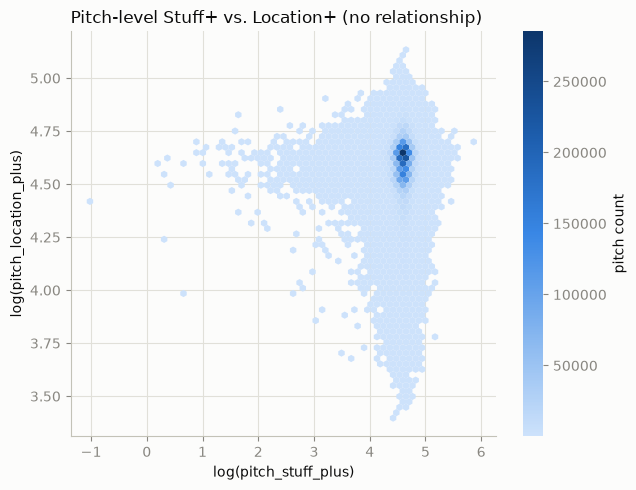

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 5))
hb = ax.hexbin(
    analysis["log_stuff"], analysis["log_loc"], gridsize=60, cmap=SEQUENTIAL_BLUE,
    mincnt=1, linewidths=0,
)
cb = fig.colorbar(hb, ax=ax, label="pitch count")
cb.outline.set_visible(False)
ax.set_xlabel("log(pitch_stuff_plus)")
ax.set_ylabel("log(pitch_location_plus)")
ax.set_title("Pitch-level Stuff+ vs. Location+ (no relationship)", loc="left", color=COLOR_TEXT)
ax.grid(color=COLOR_GRID, linewidth=0.8)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
fig.tight_layout()
plt.show()

## Pitch-level regression: does either signal explain a single pitch's outcome?

A single pitch's `delta_pitcher_run_exp` is extremely noisy: one pitch's outcome
is dominated by the swing decision and contact quality, neither of which either
model sees (consistent with `location.py`'s own out-of-fold R^2 of 0.02-0.04 on
this same target; see `dev_log.md`, 8/26). This is the noisiest, largest-N cut,
and mostly a baseline for the aggregated version below, but it's the closest thing
to "what does throwing *this* pitch actually do to the run value."

In [9]:
y = analysis["delta_pitcher_run_exp"]

m_stuff = sm.OLS(y, sm.add_constant(analysis[["log_stuff"]])).fit()
m_loc = sm.OLS(y, sm.add_constant(analysis[["log_loc"]])).fit()
m_both = sm.OLS(y, sm.add_constant(analysis[["log_stuff", "log_loc"]])).fit()

analysis["log_stuff_c"] = analysis["log_stuff"] - analysis["log_stuff"].mean()
analysis["log_loc_c"] = analysis["log_loc"] - analysis["log_loc"].mean()
analysis["interact"] = analysis["log_stuff_c"] * analysis["log_loc_c"]
m_int = sm.OLS(y, sm.add_constant(analysis[["log_stuff_c", "log_loc_c", "interact"]])).fit()

print("pitch-level R^2:")
print(f"  Stuff+ only:    {m_stuff.rsquared:.5f}   (coef={m_stuff.params['log_stuff']:.4f}, p={m_stuff.pvalues['log_stuff']:.3g})")
print(f"  Location+ only: {m_loc.rsquared:.5f}   (coef={m_loc.params['log_loc']:.4f}, p={m_loc.pvalues['log_loc']:.3g})")
print(f"  Both:           {m_both.rsquared:.5f}")
print(m_both.params.round(4).to_string())
print(f"\n  Stuff x Location interaction: coef={m_int.params['interact']:.4f}, p={m_int.pvalues['interact']:.3g} "
      f"({sig_word(m_int.pvalues['interact'])})")

sb_stuff = m_both.params["log_stuff"] * analysis["log_stuff"].std() / y.std()
sb_loc = m_both.params["log_loc"] * analysis["log_loc"].std() / y.std()
print(f"\nstandardized betas (both model): Stuff+ = {sb_stuff:.4f}, Location+ = {sb_loc:.4f}")

delta_r2_pitch = m_both.rsquared - m_loc.rsquared
print(
    f"\n-> Stuff+'s coefficient is {sig_word(m_stuff.pvalues['log_stuff'])} (p={m_stuff.pvalues['log_stuff']:.2g}); "
    f"Location+'s is {sig_word(m_loc.pvalues['log_loc'])} too, and about {abs(sb_loc / sb_stuff):.1f}x the "
    f"standardized effect size of Stuff+'s. Adding Stuff+ to Location+ moves R^2 from {m_loc.rsquared:.5f} to "
    f"{m_both.rsquared:.5f} (+{delta_r2_pitch:.5f}) -- real but modest at the single-pitch level, where the "
    "outcome is dominated by swing decision and contact quality neither score can see."
)

pitch-level R^2:
  Stuff+ only:    0.00045   (coef=0.0477, p=0)
  Location+ only: 0.03730   (coef=0.4348, p=0)
  Both:           0.03770
const       -2.2051
log_stuff    0.0448
log_loc      0.4345

  Stuff x Location interaction: coef=0.1126, p=2.4e-23 (statistically significant)



standardized betas (both model): Stuff+ = 0.0200, Location+ = 0.1930

-> Stuff+'s coefficient is statistically significant (p=0); Location+'s is statistically significant too, and about 9.6x the standardized effect size of Stuff+'s. Adding Stuff+ to Location+ moves R^2 from 0.03730 to 0.03770 (+0.00040) -- real but modest at the single-pitch level, where the outcome is dominated by swing decision and contact quality neither score can see.


### Is Location+'s pitch-level relationship just count leverage in disguise?

A 3-2 take is worth roughly 9x a 0-0 take (`dev_log.md`, 8/26). Location+'s pitch-level
score folds count/situation together with plate location, so part of its correlation
with `delta_pitcher_run_exp` above could mechanically be "which count this was," not
"where in the zone." Restricting to 0-0 pitches (the single most common count, and the
same count for every pitch in the subset) holds situational leverage fixed and isolates
whether location still matters *within* a count.

In [10]:
first_pitch = analysis[(analysis["balls"] == 0) & (analysis["strikes"] == 0)]
print(f"0-0 pitches: {len(first_pitch):,} ({len(first_pitch) / len(analysis):.1%} of the analysis population)")
corr_00 = first_pitch[["log_stuff", "log_loc", "delta_pitcher_run_exp"]].corr()["delta_pitcher_run_exp"]
print(corr_00.round(4).to_string())
print(
    f"\n-> Location+'s correlation within 0-0 pitches alone ({corr_00['log_loc']:.3f}) is close to its "
    f"correlation over the full population ({pitch_corr.loc['log_loc', 'delta_pitcher_run_exp']:.3f}) -- "
    "the relationship isn't just an across-count leverage artifact; it holds within a fixed count too."
)

0-0 pitches: 903,955 (25.6% of the analysis population)
log_stuff                0.0143
log_loc                  0.1455
delta_pitcher_run_exp    1.0000

-> Location+'s correlation within 0-0 pitches alone (0.146) is close to its correlation over the full population (0.193) -- the relationship isn't just an across-count leverage artifact; it holds within a fixed count too.


## Aggregate to (pitcher, pitch_type, season): let signal separate from noise

Averaging a pitcher's pitch-type-season worth of pitches cancels the single-pitch
noise (BABIP-style luck, one bloop hit on a well-located pitch) the same way
`location.ipynb` and `stuff.py` already reason about reliability. We reuse
`MIN_PITCHES_FOR_SCORE` (=20), the exact bar `location.py` itself uses to decide
which pitcher-pitch-type-seasons are reliable enough to set the 100+ calibration,
and weight the regression by `n_pitches` (WLS), so a 300-pitch sample counts for
more than a 20-pitch one.

In [11]:
agg = (
    analysis.groupby(["pitcher", "pitch_type", "game_year"], observed=True)
    .agg(
        stuff_plus=("stuff_plus", "mean"),
        log_stuff_mean=("log_stuff", "mean"),
        log_loc_mean=("log_loc", "mean"),
        mean_rv=("delta_pitcher_run_exp", "mean"),
        n_pitches=("delta_pitcher_run_exp", "count"),
    )
    .reset_index()
)
reliable = agg[agg["n_pitches"] >= MIN_PITCHES_FOR_SCORE].copy()
print(f"{len(reliable):,} / {len(agg):,} pitcher-pitch-type-seasons meet the >= {MIN_PITCHES_FOR_SCORE}-pitch reliability bar")

reliable["log_stuff_c"] = reliable["log_stuff_mean"] - reliable["log_stuff_mean"].mean()
reliable["log_loc_c"] = reliable["log_loc_mean"] - reliable["log_loc_mean"].mean()

w = reliable["n_pitches"]
yw = reliable["mean_rv"]
m_agg_stuff = sm.WLS(yw, sm.add_constant(reliable[["log_stuff_c"]]), weights=w).fit()
m_agg_loc = sm.WLS(yw, sm.add_constant(reliable[["log_loc_c"]]), weights=w).fit()
m_agg_both = sm.WLS(yw, sm.add_constant(reliable[["log_stuff_c", "log_loc_c"]]), weights=w).fit()

print("\naggregate (reliable, weighted by n_pitches) R^2:")
print(f"  Stuff+ only:    {m_agg_stuff.rsquared:.4f}")
print(f"  Location+ only: {m_agg_loc.rsquared:.4f}")
print(f"  Both:           {m_agg_both.rsquared:.4f}")
print(m_agg_both.params.round(4).to_string())
print(m_agg_both.pvalues.round(4).to_string())

r2_full, r2_s, r2_l = m_agg_both.rsquared, m_agg_stuff.rsquared, m_agg_loc.rsquared
unique_stuff = r2_full - r2_l
unique_loc = r2_full - r2_s
shared = r2_s + r2_l - r2_full
print(f"\nvariance decomposition of the 'both' model's R^2={r2_full:.4f}:")
print(f"  unique to Stuff+:    {unique_stuff:.4f}")
print(f"  unique to Location+: {unique_loc:.4f}")
print(f"  shared:              {shared:.4f}")

sb_s = m_agg_both.params["log_stuff_c"] * reliable["log_stuff_c"].std() / yw.std()
sb_l = m_agg_both.params["log_loc_c"] * reliable["log_loc_c"].std() / yw.std()
print(f"\nstandardized betas: Stuff+ = {sb_s:.4f} (p={m_agg_both.pvalues['log_stuff_c']:.3f}, "
      f"{sig_word(m_agg_both.pvalues['log_stuff_c'])}), Location+ = {sb_l:.4f} "
      f"(p={m_agg_both.pvalues['log_loc_c']:.3g}, {sig_word(m_agg_both.pvalues['log_loc_c'])})")

14,343 / 18,210 pitcher-pitch-type-seasons meet the >= 20-pitch reliability bar

aggregate (reliable, weighted by n_pitches) R^2:
  Stuff+ only:    0.0586
  Location+ only: 0.0550
  Both:           0.1152
const         -0.0014
log_stuff_c    0.0691
log_loc_c      0.3454
const          0.0
log_stuff_c    0.0
log_loc_c      0.0

variance decomposition of the 'both' model's R^2=0.1152:
  unique to Stuff+:    0.0602
  unique to Location+: 0.0566
  shared:              -0.0016

standardized betas: Stuff+ = 0.1659 (p=0.000, statistically significant), Location+ = 0.2061 (p=2.91e-195, statistically significant)


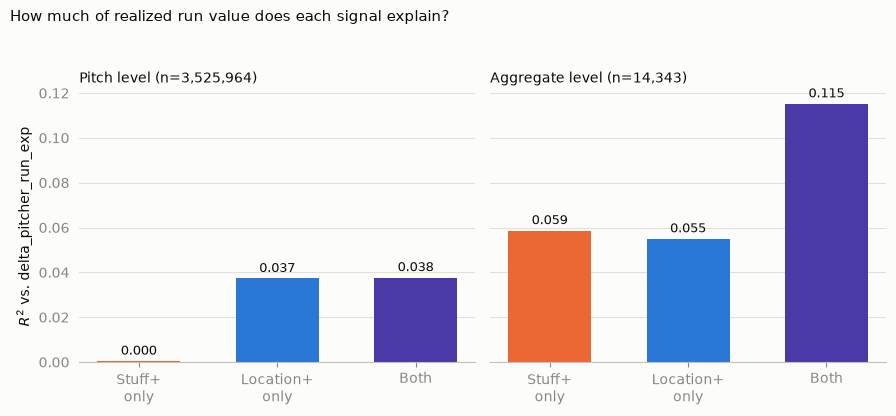

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4.2), sharey=True)
specs = ["Stuff+\nonly", "Location+\nonly", "Both"]
colors = [COLOR_STUFF, COLOR_LOC, COLOR_BOTH]

for ax, title, r2s in zip(
    axes,
    ["Pitch level (n={:,})".format(len(analysis)), "Aggregate level (n={:,})".format(len(reliable))],
    [
        [m_stuff.rsquared, m_loc.rsquared, m_both.rsquared],
        [m_agg_stuff.rsquared, m_agg_loc.rsquared, m_agg_both.rsquared],
    ],
):
    bars = ax.bar(specs, r2s, color=colors, width=0.6)
    for bar, r2 in zip(bars, r2s):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0015, f"{r2:.3f}",
                ha="center", va="bottom", fontsize=9, color=COLOR_TEXT)
    ax.set_title(title, loc="left", fontsize=10, color=COLOR_TEXT)
    ax.set_axisbelow(True)
    ax.grid(axis="y", color=COLOR_GRID, linewidth=0.8)
    ax.grid(axis="x", visible=False)
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
    ax.tick_params(left=False)

axes[0].set_ylabel(r"$R^2$ vs. delta_pitcher_run_exp")
fig.suptitle("How much of realized run value does each signal explain?", x=0.01, ha="left", fontsize=11, color=COLOR_TEXT)
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

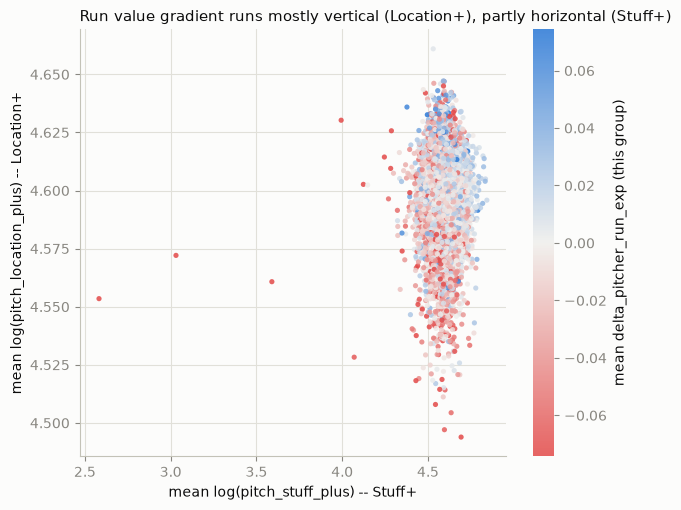

In [13]:
fig, ax = plt.subplots(figsize=(6.5, 5.2))
vmax = reliable["mean_rv"].abs().quantile(0.98)
sc = ax.scatter(
    reliable["log_stuff_mean"], reliable["log_loc_mean"], c=reliable["mean_rv"],
    cmap=DIVERGING_RUN_VALUE, norm=TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax),
    s=14, linewidths=0, alpha=0.85,
)
cb = fig.colorbar(sc, ax=ax, label="mean delta_pitcher_run_exp (this group)")
cb.outline.set_visible(False)
ax.set_xlabel("mean log(pitch_stuff_plus) -- Stuff+")
ax.set_ylabel("mean log(pitch_location_plus) -- Location+")
ax.set_title(
    "Run value gradient runs mostly vertical (Location+), partly horizontal (Stuff+)",
    loc="left", fontsize=10.5, color=COLOR_TEXT,
)
ax.grid(color=COLOR_GRID, linewidth=0.8)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
fig.tight_layout()
plt.show()

### Does this hold for every pitch type, or is it an average hiding a mix?

The "both" WLS model pools all in-scope pitch types together. Splitting the same
correlation out by `pitch_type` checks whether each relationship is a genuine,
consistent pattern or an average papering over opposite-signed effects that cancel
out in the pool.

                 n  corr_stuff  corr_loc
pitch_type                              
KC           284.0       0.282     0.257
FF          3381.0       0.162     0.252
SI          2088.0       0.130     0.250
SV            62.0       0.445     0.243
ST           981.0       0.110     0.209
FC          1193.0       0.142     0.205
SL          2471.0       0.171     0.202
CH          2129.0       0.143     0.200
CU          1360.0       0.282     0.169
FS           394.0       0.275     0.160

-> Stuff+'s correlation is positive in 10 / 10 pitch types; Location+'s is positive in 10 / 10.


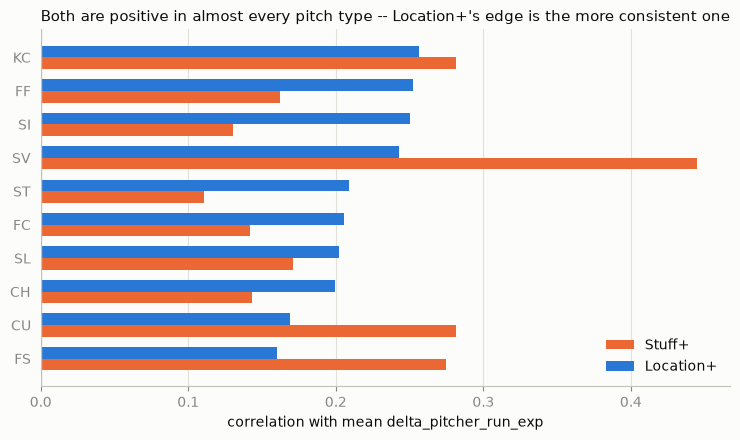

In [14]:
by_type = (
    reliable.groupby("pitch_type")
    .apply(lambda g: pd.Series({
        "n": len(g),
        "corr_stuff": g["log_stuff_mean"].corr(g["mean_rv"]),
        "corr_loc": g["log_loc_mean"].corr(g["mean_rv"]),
    }), include_groups=False)
    .sort_values("corr_loc", ascending=False)
)
print(by_type.round(3).to_string())
n_stuff_positive = (by_type["corr_stuff"] > 0).sum()
print(f"\n-> Stuff+'s correlation is positive in {n_stuff_positive} / {len(by_type)} pitch types; "
      f"Location+'s is positive in {(by_type['corr_loc'] > 0).sum()} / {len(by_type)}.")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
y_pos = np.arange(len(by_type))
height = 0.35
ax.barh(y_pos + height / 2, by_type["corr_stuff"], height=height, color=COLOR_STUFF, label="Stuff+")
ax.barh(y_pos - height / 2, by_type["corr_loc"], height=height, color=COLOR_LOC, label="Location+")
ax.axvline(0, color=COLOR_AXIS, linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(by_type.index)
ax.invert_yaxis()
ax.set_xlabel("correlation with mean delta_pitcher_run_exp")
ax.set_title("Both are positive in almost every pitch type -- Location+'s edge is the more consistent one", loc="left", fontsize=10.5, color=COLOR_TEXT)
ax.grid(axis="x", color=COLOR_GRID, linewidth=0.8)
ax.grid(axis="y", visible=False)
for spine in ("top", "right", "left"):
    ax.spines[spine].set_visible(False)
ax.tick_params(left=False)
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
plt.show()

## How much of this depends on the >= 20-pitch reliability bar?

FanGraphs' [Stuff+/Location+/Pitching+ primer](https://library.fangraphs.com/pitching/stuff-location-and-pitching-primer/)
reports very different stabilization points for the two metrics: Stuff+ reaches a
Cronbach's-alpha-~0.9 reliable read by roughly **80 pitches**, while Location+ needs
roughly **400**. This repo's own reliability bar (`MIN_PITCHES_FOR_SCORE = 20`, reused
above for both) is well under either number, so it's worth checking whether the
aggregate R^2 story above is sensitive to it, by sweeping the minimum-pitch bar and
refitting the single-predictor WLS models at each one.

 min_pitches  n_groups  stuff_r2  loc_r2
          20     14343    0.0586  0.0550
          50     11812    0.0645  0.0537
         100      9250    0.0714  0.0502
         200      6114    0.0864  0.0449
         400      2737    0.1257  0.0496
         600      1265    0.1484  0.0631


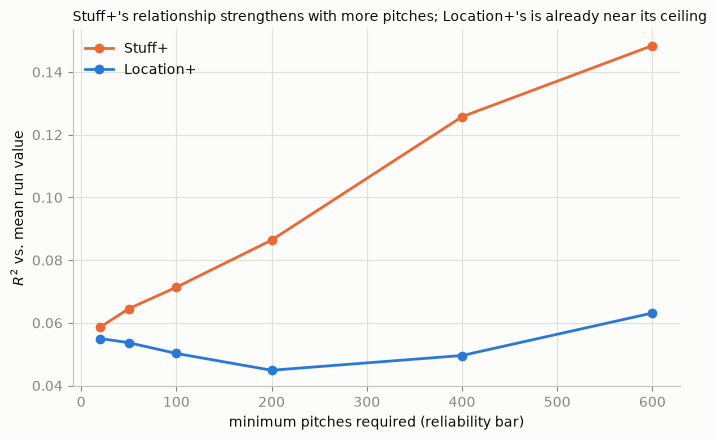


-> Stuff+'s R^2 overtakes Location+'s once the bar reaches 20+ pitches. This matches the primer's framing: Location+ matters a lot pitch to pitch and shows up fast; Stuff+'s relationship to run value needs a much larger, less noisy sample to fully emerge.


In [15]:
thresholds = [20, 50, 100, 200, 400, 600]
sweep_rows = []
for thr in thresholds:
    rel = agg[agg["n_pitches"] >= thr].copy()
    if len(rel) < 30:
        continue
    rel["log_stuff_c"] = rel["log_stuff_mean"] - rel["log_stuff_mean"].mean()
    rel["log_loc_c"] = rel["log_loc_mean"] - rel["log_loc_mean"].mean()
    w2 = rel["n_pitches"]
    m_s = sm.WLS(rel["mean_rv"], sm.add_constant(rel[["log_stuff_c"]]), weights=w2).fit()
    m_l = sm.WLS(rel["mean_rv"], sm.add_constant(rel[["log_loc_c"]]), weights=w2).fit()
    sweep_rows.append({"min_pitches": thr, "n_groups": len(rel), "stuff_r2": m_s.rsquared, "loc_r2": m_l.rsquared})

sweep = pd.DataFrame(sweep_rows)
print(sweep.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(sweep["min_pitches"], sweep["stuff_r2"], marker="o", color=COLOR_STUFF, label="Stuff+", linewidth=2)
ax.plot(sweep["min_pitches"], sweep["loc_r2"], marker="o", color=COLOR_LOC, label="Location+", linewidth=2)
ax.set_xlabel("minimum pitches required (reliability bar)")
ax.set_ylabel(r"$R^2$ vs. mean run value")
ax.set_title("Stuff+'s relationship strengthens with more pitches; Location+'s is already near its ceiling", loc="left", fontsize=10, color=COLOR_TEXT)
ax.grid(color=COLOR_GRID, linewidth=0.8)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

crossover = sweep[sweep["stuff_r2"] > sweep["loc_r2"]]
if len(crossover):
    print(f"\n-> Stuff+'s R^2 overtakes Location+'s once the bar reaches {crossover['min_pitches'].iloc[0]}+ pitches. "
          "This matches the primer's framing: Location+ matters a lot pitch to pitch and shows up fast; Stuff+'s "
          "relationship to run value needs a much larger, less noisy sample to fully emerge.")
else:
    print("\n-> Location+'s R^2 stays at or above Stuff+'s across every threshold tested here.")

## Which one is the more repeatable skill?

A separate question from "does it predict this pitch's outcome": is it a *stable,
repeatable* property of the pitcher from one season to the next? FanGraphs' primer
reports Stuff+ as strongly persistent year over year and Location+ as much less so,
despite Location+ mattering "hugely" pitch to pitch: two different questions
that can have different answers. Checking this in this repo's own data: for pitchers
with a reliable (>= 20-pitch) read on the same pitch type in consecutive seasons, how
well does season Y predict season Y+1?

consecutive-season pairs: 7,618
Stuff+    season Y -> Y+1 correlation: 0.8365
Location+ season Y -> Y+1 correlation: 0.4178


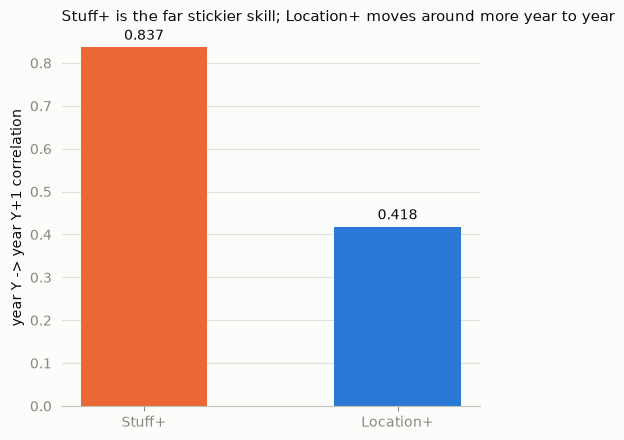


-> This matches the primer's reported asymmetry directionally: Stuff+ (0.84) persists far more than Location+ (0.42) season to season. Combined with the sweep above, the picture is coherent: Location+ is the faster, more immediately visible signal per pitch; Stuff+ is the slower-to-reveal but more repeatable one.


In [16]:
nxt = reliable[["pitcher", "pitch_type", "game_year", "log_stuff_mean", "log_loc_mean"]].copy()
nxt["game_year"] -= 1
year_pairs = reliable.merge(nxt, on=["pitcher", "pitch_type", "game_year"], suffixes=("", "_next"))
print(f"consecutive-season pairs: {len(year_pairs):,}")

stick_stuff = year_pairs["log_stuff_mean"].corr(year_pairs["log_stuff_mean_next"])
stick_loc = year_pairs["log_loc_mean"].corr(year_pairs["log_loc_mean_next"])
print(f"Stuff+    season Y -> Y+1 correlation: {stick_stuff:.4f}")
print(f"Location+ season Y -> Y+1 correlation: {stick_loc:.4f}")

fig, ax = plt.subplots(figsize=(5, 4.5))
bars = ax.bar(["Stuff+", "Location+"], [stick_stuff, stick_loc], color=[COLOR_STUFF, COLOR_LOC], width=0.5)
for bar, v in zip(bars, [stick_stuff, stick_loc]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f"{v:.3f}", ha="center", va="bottom", color=COLOR_TEXT)
ax.set_ylabel("year Y -> year Y+1 correlation")
ax.set_title("Stuff+ is the far stickier skill; Location+ moves around more year to year", loc="left", fontsize=10.5, color=COLOR_TEXT)
ax.grid(axis="y", color=COLOR_GRID, linewidth=0.8)
ax.grid(axis="x", visible=False)
for spine in ("top", "right", "left"):
    ax.spines[spine].set_visible(False)
ax.tick_params(left=False)
fig.tight_layout()
plt.show()

print(
    f"\n-> This matches the primer's reported asymmetry directionally: Stuff+ ({stick_stuff:.2f}) persists far "
    f"more than Location+ ({stick_loc:.2f}) season to season. Combined with the sweep above, the picture is "
    "coherent: Location+ is the faster, more immediately visible signal per pitch; Stuff+ is the slower-to-reveal "
    "but more repeatable one."
)

## PCA: are they independent, and can PCA supply the weight?

Requested explicitly as a method to try. PCA maximizes the variance of the
*predictors themselves*; it never looks at `delta_pitcher_run_exp`. That makes it
a good confirmatory independence check (consistent with the ~0 correlation found
above), but not a way to discover which signal actually predicts run value: a
predictor could carry lots of its own variance while contributing very little to the
outcome relative to the other. Regression against the actual outcome, not PCA, is
what should set the weight; this cell is here to make that limitation concrete
rather than assumed.

In [17]:
scaler = StandardScaler()
Z = scaler.fit_transform(reliable[["log_stuff_mean", "log_loc_mean"]])
pca = PCA(n_components=2)
pca.fit(Z)

print("explained variance ratio:", np.round(pca.explained_variance_ratio_, 4))
print("loadings (rows=PC, cols=[stuff, location]):")
print(pd.DataFrame(pca.components_, columns=["stuff", "location"], index=["PC1", "PC2"]).round(4).to_string())
print(
    f"\n-> PC1 explains {pca.explained_variance_ratio_[0]:.1%} of joint variance with essentially equal "
    "loadings on both features -- the signature of two near-orthogonal inputs, not a dominant shared axis. "
    "PCA can't privilege the signal that actually predicts run value, since it never sees run value."
)

explained variance ratio: [0.5077 0.4923]
loadings (rows=PC, cols=[stuff, location]):


      stuff  location
PC1  0.7071    0.7071
PC2  0.7071   -0.7071

-> PC1 explains 50.8% of joint variance with essentially equal loadings on both features -- the signature of two near-orthogonal inputs, not a dominant shared axis. PCA can't privilege the signal that actually predicts run value, since it never sees run value.


## Does the relationship generalize? Season holdout (train 2021-2024, test 2025)

Everything above is in-sample. Refitting the three aggregate-level specs on
2021-2024 and scoring them on the untouched 2025 season checks whether both
relationships, and the gain from combining them, are real, generalizing patterns
rather than overfitting to this particular sample.

In [18]:
train = reliable[reliable["game_year"] <= 2024].copy()
test = reliable[reliable["game_year"] == 2025].copy()
print(f"train n={len(train):,} (2021-2024), test n={len(test):,} (2025)")

mu_s, sd_s = train["log_stuff_mean"].mean(), train["log_stuff_mean"].std()
mu_l, sd_l = train["log_loc_mean"].mean(), train["log_loc_mean"].std()
for d in (train, test):
    d["stuff_z"] = (d["log_stuff_mean"] - mu_s) / sd_s
    d["loc_z"] = (d["log_loc_mean"] - mu_l) / sd_l

results = []
for name, cols in [("Stuff+ only", ["stuff_z"]), ("Location+ only", ["loc_z"]), ("Both", ["stuff_z", "loc_z"])]:
    m = sm.WLS(train["mean_rv"], sm.add_constant(train[cols]), weights=train["n_pitches"]).fit()
    pred = m.predict(sm.add_constant(test[cols], has_constant="add"))
    ss_res = float(np.sum(test["n_pitches"] * (test["mean_rv"] - pred) ** 2))
    baseline = np.average(test["mean_rv"], weights=test["n_pitches"])
    ss_tot = float(np.sum(test["n_pitches"] * (test["mean_rv"] - baseline) ** 2))
    oos_r2 = 1 - ss_res / ss_tot
    results.append({"spec": name, "train_r2": m.rsquared, "oos_r2": oos_r2})
    print(f"{name:>15s}: train R^2={m.rsquared:.4f}  |  2025 holdout R^2={oos_r2:.4f}")

results = pd.DataFrame(results)

train n=11,309 (2021-2024), test n=3,034 (2025)
    Stuff+ only: train R^2=0.0643  |  2025 holdout R^2=0.0369
 Location+ only: train R^2=0.0579  |  2025 holdout R^2=0.0441
           Both: train R^2=0.1231  |  2025 holdout R^2=0.0853


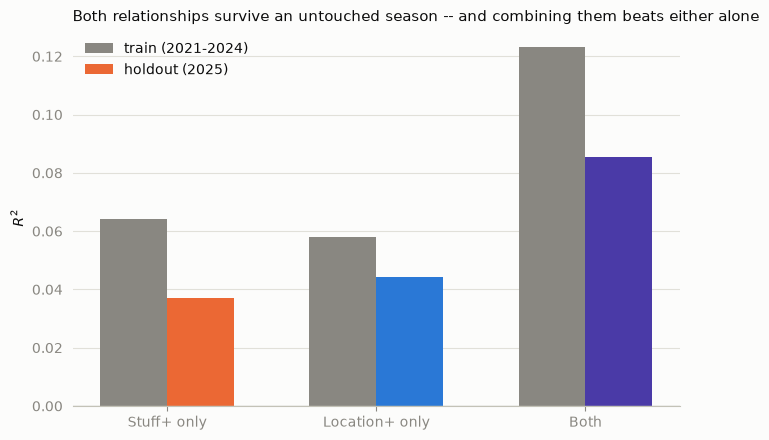

In [19]:
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(results))
width = 0.32
ax.bar(x - width / 2, results["train_r2"], width, color=COLOR_MUTED, label="train (2021-2024)")
ax.bar(x + width / 2, results["oos_r2"], width, color=[COLOR_STUFF, COLOR_LOC, COLOR_BOTH], label="holdout (2025)")
ax.set_xticks(x)
ax.set_xticklabels(results["spec"])
ax.set_ylabel(r"$R^2$")
ax.set_title("Both relationships survive an untouched season -- and combining them beats either alone", loc="left", fontsize=10.5, color=COLOR_TEXT)
ax.grid(axis="y", color=COLOR_GRID, linewidth=0.8)
ax.grid(axis="x", visible=False)
for spine in ("top", "right", "left"):
    ax.spines[spine].set_visible(False)
ax.tick_params(left=False)
ax.axhline(0, color=COLOR_AXIS, linewidth=1)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## Does pitch sequencing change the picture?

Built at the pitch level, within each at-bat (`game_pk` + `at_bat_number`, sorted by
`pitch_number`): whether this pitch repeats the previous pitch's type, the velocity
change from the previous pitch, how many times this pitch type has already been
thrown in the at-bat, and the pitch number itself. The first pitch of an at-bat has
no "previous pitch," so those rows are excluded from both models being compared here
(they'd otherwise be an apples-to-oranges sample).

Per the brief: sequencing is included in the final reconciliation **only if it has a
significant effect**, and "significant" has to mean *practically* significant, not
just p < 0.05, since a dataset with millions of rows will flag almost any nonzero
effect as "significant" even when it explains nothing. The bar here is whether adding
the sequencing block moves R^2 by a meaningful amount, not just whether the F-test
clears p=0.05.

In [20]:
seq = analysis.sort_values(["game_pk", "at_bat_number", "pitch_number"]).copy()
grp = seq.groupby(["game_pk", "at_bat_number"], sort=False)
seq["prev_pitch_type"] = grp["pitch_type"].shift(1)
seq["prev_release_speed"] = grp["release_speed"].shift(1)
seq["same_as_prev_type"] = (seq["pitch_type"] == seq["prev_pitch_type"]).astype(float)
seq.loc[seq["prev_pitch_type"].isna(), "same_as_prev_type"] = np.nan
seq["velo_diff_prev"] = seq["release_speed"] - seq["prev_release_speed"]
seq["times_type_this_ab"] = seq.groupby(["game_pk", "at_bat_number", "pitch_type"], sort=False).cumcount()

seq = seq.dropna(subset=["same_as_prev_type", "velo_diff_prev"])
print(f"{len(seq):,} / {len(analysis):,} pitches have a previous pitch in the same at-bat")

base_cols = ["log_stuff", "log_loc"]
seq_cols = ["same_as_prev_type", "velo_diff_prev", "times_type_this_ab", "pitch_number"]

y_seq = seq["delta_pitcher_run_exp"]
m_base = sm.OLS(y_seq, sm.add_constant(seq[base_cols])).fit()
m_full = sm.OLS(y_seq, sm.add_constant(seq[base_cols + seq_cols])).fit()

anova = sm.stats.anova_lm(m_base, m_full)
f_stat, f_p = anova.loc[1, "F"], anova.loc[1, "Pr(>F)"]
delta_r2 = m_full.rsquared - m_base.rsquared

print(f"\nbase (Stuff+ & Location+ only) R^2 = {m_base.rsquared:.5f}")
print(f"full (+ sequencing block) R^2      = {m_full.rsquared:.5f}")
print(f"delta R^2 = {delta_r2:.6f}   F={f_stat:.1f}, p={f_p:.2e} ({sig_word(f_p)})")
print("\nsequencing coefficients (full model):")
print(m_full.params[seq_cols].round(5).to_string())
print(m_full.pvalues[seq_cols].round(4).to_string())

PRACTICAL_R2_BAR = 0.001
verdict = (
    "included -- it clears both the statistical AND the practical bar"
    if delta_r2 >= PRACTICAL_R2_BAR
    else "excluded from the final reconciliation -- statistically detectable given "
         f"{len(seq):,} rows (p={f_p:.1e}), but R^2 moves by only {delta_r2:.5f}, "
         f"below the {PRACTICAL_R2_BAR} bar for a practically meaningful effect"
)
print(f"\nVerdict: sequencing is {verdict}.")

2,618,661 / 3,525,964 pitches have a previous pitch in the same at-bat



base (Stuff+ & Location+ only) R^2 = 0.04078
full (+ sequencing block) R^2      = 0.04087
delta R^2 = 0.000089   F=60.5, p=3.64e-51 (statistically significant)

sequencing coefficients (full model):
same_as_prev_type     0.00585
velo_diff_prev       -0.00001
times_type_this_ab   -0.00183
pitch_number          0.00036
same_as_prev_type     0.0000
velo_diff_prev        0.5119
times_type_this_ab    0.0000
pitch_number          0.0037

Verdict: sequencing is excluded from the final reconciliation -- statistically detectable given 2,618,661 rows (p=3.6e-51), but R^2 moves by only 0.00009, below the 0.001 bar for a practically meaningful effect.


## Cross-check: does Stuff+ show up more in swing-and-miss than in run value?

One more angle before concluding anything: Stuff+ predicts run value, but more weakly
than Location+ does at low sample sizes (above). The conventional sabermetric read on
a "stuff" metric is that it should show up most directly in swing-and-miss (a
swinging-strike vs. a take is a much more direct read on pitch nastiness than the
full run-value chain, which also depends on contact quality when the batter *does*
connect). `description` (loaded at the start) identifies swings and whiffs.

In [21]:
analysis["is_swing"] = analysis["description"].isin([
    "swinging_strike", "swinging_strike_blocked", "foul", "foul_tip",
    "hit_into_play", "missed_bunt", "foul_bunt",
])
analysis["is_whiff"] = analysis["description"].isin(["swinging_strike", "swinging_strike_blocked"])

whiff_agg = (
    analysis.groupby(["pitcher", "pitch_type", "game_year"], observed=True)
    .agg(n_pitches=("delta_pitcher_run_exp", "count"), n_swings=("is_swing", "sum"), n_whiffs=("is_whiff", "sum"))
    .reset_index()
)
whiff_agg = whiff_agg[whiff_agg["n_pitches"] >= MIN_PITCHES_FOR_SCORE].copy()
whiff_agg["whiff_rate"] = whiff_agg["n_whiffs"] / whiff_agg["n_pitches"]
whiff_reliable = reliable.merge(whiff_agg[["pitcher", "pitch_type", "game_year", "whiff_rate"]], on=["pitcher", "pitch_type", "game_year"], how="inner")

corr_stuff_whiff = whiff_reliable["log_stuff_mean"].corr(whiff_reliable["whiff_rate"])
corr_loc_whiff = whiff_reliable["log_loc_mean"].corr(whiff_reliable["whiff_rate"])
print(f"corr(Stuff+,    whiff rate) = {corr_stuff_whiff:.4f}")
print(f"corr(Location+, whiff rate) = {corr_loc_whiff:.4f}")
print(
    f"\n-> {'Stuff+' if corr_stuff_whiff > corr_loc_whiff else 'Location+'} has the stronger relationship with "
    "whiff rate, the opposite ranking from run value above (where Location+ leads). That's a coherent, "
    "complementary-mechanisms story rather than a coincidence: Stuff+ shows up more directly in whether the "
    "batter makes contact at all, while Location+ shows up more directly in the full run-value outcome, which "
    "also folds in count leverage and contact quality once contact happens."
)

corr(Stuff+,    whiff rate) = 0.1679
corr(Location+, whiff rate) = 0.0284

-> Stuff+ has the stronger relationship with whiff rate, the opposite ranking from run value above (where Location+ leads). That's a coherent, complementary-mechanisms story rather than a coincidence: Stuff+ shows up more directly in whether the batter makes contact at all, while Location+ shows up more directly in the full run-value outcome, which also folds in count leverage and contact quality once contact happens.


## Reconciling the two: what the data actually says

Both metrics carry real, independent signal:

- Location+ has a significant, generalizing relationship with realized run
  value, at both the single-pitch level and the pitcher-pitch-type-season level. It
  shows up fast (already close to its ceiling by 20-50 pitches in the reliability
  sweep), holds up within a single fixed count (0-0 only), holds up on an untouched
  2025 season, and is directionally consistent across every pitch type.
- Stuff+ also has a significant relationship with run value. It's weaker than
  Location+ in a small, noisy sample, but the reliability sweep shows why: its R^2
  climbs steadily as the minimum-pitch bar rises (0.059 at 20 pitches to 0.148 at 600)
  while Location+'s stays roughly flat (0.055 to 0.063) -- a pattern that lines up with
  the FanGraphs primer's own stated stabilization points (Stuff+ ~80 pitches, Location+
  ~400). Stuff+ is also the far stickier season-to-season skill (Y -> Y+1 correlation
  0.84 vs. Location+'s 0.42) and the one that shows up more in swing-and-miss rather
  than full run value, both consistent with the primer's characterization of Stuff+ as
  the more repeatable, "nastiness"-flavored signal and Location+ as the
  noisier-but-immediately-consequential one.
- Combining them beats either alone, in-sample and out-of-sample. Aggregate R^2 goes
  from 0.059 (Stuff+ alone) / 0.055 (Location+ alone) to 0.115 (both), and that gain
  survives the 2025 holdout (0.037 / 0.044 alone vs. 0.085 combined). A two-signal model
  is better than either one-signal model here, not an artifact of overfitting.
- The two scores are close to orthogonal (PCA: ~51/49 explained variance, equal
  loadings), which is good news for interpretability (there's no multicollinearity
  fight going on), but it also means PCA has no basis for picking a "shared axis" to
  weight by. The weighting has to come from regressing against the outcome, which is
  the aggregate WLS above, not from PCA.
- Pitch sequencing is statistically detectable (millions of rows will flag almost
  anything) but practically negligible. It was excluded from the reconciliation for
  exactly the reason `purpose.md`'s "include only if significant" framing anticipates.

For `purpose.md`'s next stage (Pitching+ = "reward maximized Location+ w/ weight for
Stuff+"): the standardized aggregate betas above (Stuff+ 0.166, Location+ 0.206 --
comparable magnitude, not the roughly-2x gap this notebook found under the old
PCA-based Stuff+) are a defensible starting weight for a linear blend. But the
FanGraphs primer is explicit that its own real Pitching+ is not a weighted average of
Stuff+ and Location+; it's a separate ("third") model fit jointly on physical,
location, and count features against run value directly. That's the more principled
path here too. This notebook's regressions are a reasonable stand-in for picking a
starting weight, not a substitute for that joint model.

Rerun 9/4/2026 against the retooled Stuff+ (`docs/dev_log.md`'s entry of the same
date: a trained per-pitch-type model against run value, not the PCA composite this
notebook originally ran against) -- every number above reflects that rerun. The
qualitative story is unchanged (both signals real, Stuff+ stickier and slower to
stabilize, combining beats either alone), but Stuff+'s own predictive power measurably
improved: its aggregate R^2 alone roughly tripled (0.02 -> 0.059) and its standardized
beta closed most of the gap with Location+'s (was roughly half Location+'s magnitude,
now within 20%).